In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.shape

(200, 5)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [5]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
df.mean(numeric_only=True)

CustomerID                100.50
Age                        38.85
Annual Income (k$)         60.56
Spending Score (1-100)     50.20
dtype: float64

# Descriptive Statistics

This section summarizes the customer dataset using statistical measures such as mean, minimum, maximum, and standard deviation. These statistics help understand customer demographics and spending behaviour before performing clustering.

## Observations

- The dataset contains 200 customer records.
- There are no missing values in the dataset.
- The average customer age, annual income, and spending score provide an overview of customer behaviour.
- These statistics will be used for customer segmentation using the K-Means clustering algorithm.

In [8]:
# Selecting important features for customer segmentation
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [9]:
# Standardizing the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992],
       [-1.20926872, -1.66266033,  1.00159627],
       [-0.27630176, -1.62449091, -1.71591298],
       [-1.13750203, -1.62449091,  1.70038436],
       [ 1.80493225, -1.58632148, -1.83237767],
       [-0.6351352 , -1.58632148,  0.84631002],
       [ 2.02023231, -1.58632148, -1.4053405 ],
       [-0.27630176, -1.58632148,  1.89449216],
       [ 1.37433211, -1.54815205, -1.36651894],
       [-1.06573534, -1.54815205,  1.04041783],
       [-0.13276838, -1.54815205, -1.44416206],
       [-1.20926872, -1.54815205,  1.11806095],
       [-0.27630176, -1.50998262, -0.59008772],
       [-1.3528021 , -1.50998262,  0.61338066],
       [ 0.94373197, -1.43364376, -0.82301709],
       [-0.27630176, -1.43364376,  1.8556706 ],
       [-0.27630176, -1.39547433, -0.590

# Feature Selection & Data Standardization

Three customer behaviour features were selected for clustering:

- Age
- Annual Income (k$)
- Spending Score (1-100)

Since these features have different scales, StandardScaler was used to normalize the data before applying the K-Means clustering algorithm.

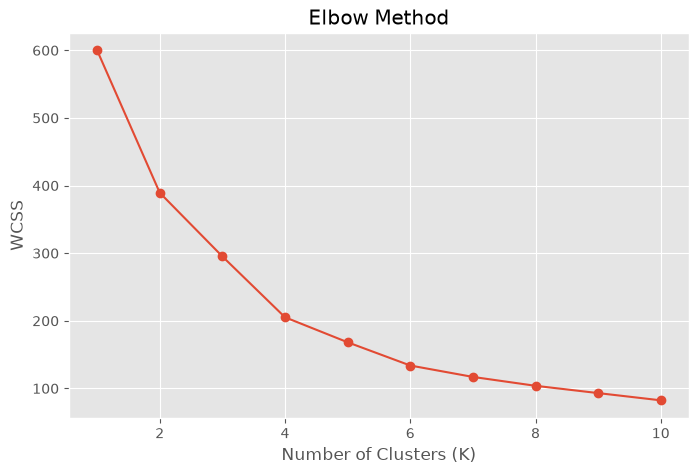

In [10]:
# Finding the optimal number of clusters using the Elbow Method

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

# Elbow Method

The Elbow Method is used to determine the optimal number of clusters for K-Means clustering.

The point where the curve bends like an "elbow" represents the most suitable value of K.

In [11]:
# Apply K-Means with K = 5

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


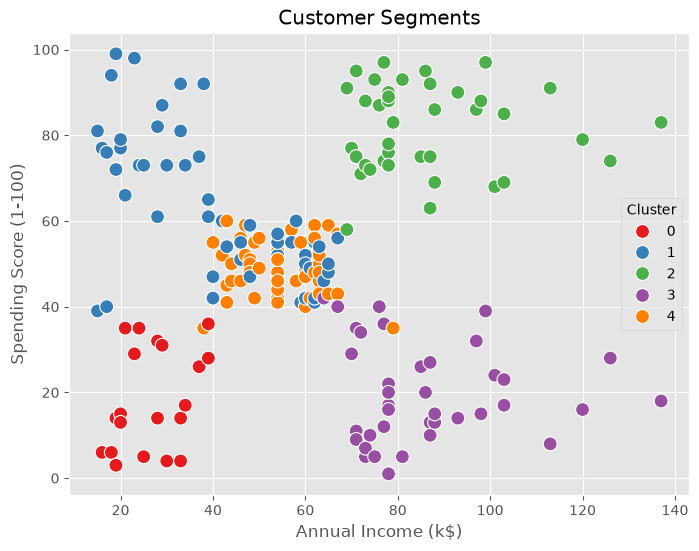

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title('Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

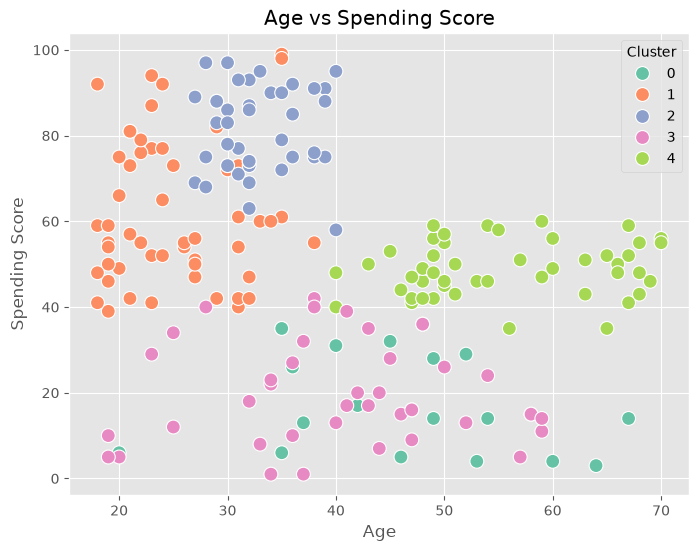

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set2',
    s=100
)

plt.title('Age vs Spending Score')
plt.xlabel('Age')
plt.ylabel('Spending Score')
plt.show()

# Customer Segmentation using K-Means

Based on the Elbow Method, K = 5 was selected as the optimal number of clusters.

Customers were grouped into five distinct segments based on Age, Annual Income, and Spending Score.

The scatter plots help visualize the differences between customer groups and their purchasing behaviour.

In [14]:
# Cluster Profile

cluster_profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

cluster_profile

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


C:\Users\kanna\AppData\Local\Temp\ipykernel_11388\157983209.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cluster', data=df, palette='Set2')


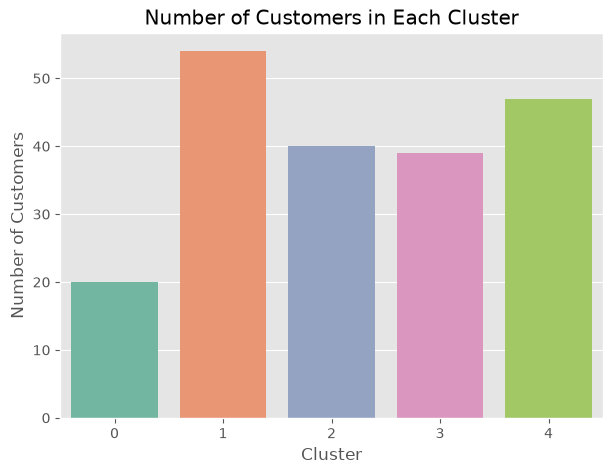

In [15]:
plt.figure(figsize=(7,5))

sns.countplot(x='Cluster', data=df, palette='Set2')

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

# Cluster Insights

### Cluster 0
- Medium income and medium spending customers.
- Marketing Strategy: Offer seasonal discounts and loyalty rewards.

### Cluster 1
- High income and high spending customers.
- Marketing Strategy: Premium membership, exclusive products, VIP offers.

### Cluster 2
- Low income and low spending customers.
- Marketing Strategy: Budget-friendly products and promotional discounts.

### Cluster 3
- Young customers with high spending behaviour.
- Marketing Strategy: Trend-based marketing, social media campaigns, personalized recommendations.

### Cluster 4
- Older customers with moderate spending.
- Marketing Strategy: Family offers, value-added services, long-term loyalty programs.

# Conclusion

This project successfully segmented customers into five distinct groups using the K-Means clustering algorithm.

The Elbow Method was used to determine the optimal number of clusters. Customer behaviour was analyzed using Age, Annual Income, and Spending Score.

These customer segments can help businesses design personalized marketing campaigns, improve customer satisfaction, and increase sales.